# Learning to Implement Denoising Diffusion Probabilistic Models

In [61]:
from collections.abc import Callable
from copy import deepcopy
from IPython.display import HTML
import matplotlib
import matplotlib.animation as animation
import math
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as parametrize
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from typing import List, Tuple, Dict, Iterable
from wand.image import Image as WImage

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from generative.conditioning import MLPTimeDependent, UNetTimeClassDependent
from generative.base_dists import GaussianBase
from generative.diffusion import (
    ConstantLinearSchedule, LearnableLinearSchedule,
    DDPMReverseProcess, VDMReverseProcess, DDIMReverseProcess
)
from generative.utils import LinearMonotonicNetwork
from utilities.prebuilt_nns import create_mnist_classifier
from utilities.metrics import DiffusionBPDEvaluator, FIDEvaluator

In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/diffusion"
SAMPLE_DIR = DATA_DIR / "samples/diffusion"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

DIFF_NAME_MAP = {
    "ddpm": "DDPM", "vdm": "VDM"
}

In [3]:
"""
coordinates = [
    [[x,y] for x in np.linspace(*(-3, 3), 1000)]
    for y in np.linspace(*(-3, 3), 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))


def animate(i):
    ax.cla()
    im = ax.imshow(
        prob, extent=[-3, 3, -3, 3], origin='lower', cmap='YlOrRd')
    ax.scatter(
        samples_all[i, :, 0], samples_all[i, :, 1], alpha=0.7, color="black")
    ax.set_xlim((-2.2, 2.2))
    ax.set_ylim((-2.2, 2.2))
    ax.set_aspect('equal')
    ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

    return fig

ani = animation.FuncAnimation(fig, animate, frames=100)

display(ani)
"""

'\ncoordinates = [\n    [[x,y] for x in np.linspace(*(-3, 3), 1000)]\n    for y in np.linspace(*(-3, 3), 1000)\n]\nprob = torch.exp(toy().log_prob(torch.tensor(coordinates)))\n\nfig, ax = plt.subplots(1, 1, figsize=(12, 7))\n\n\ndef animate(i):\n    ax.cla()\n    im = ax.imshow(\n        prob, extent=[-3, 3, -3, 3], origin=\'lower\', cmap=\'YlOrRd\')\n    ax.scatter(\n        samples_all[i, :, 0], samples_all[i, :, 1], alpha=0.7, color="black")\n    ax.set_xlim((-2.2, 2.2))\n    ax.set_ylim((-2.2, 2.2))\n    ax.set_aspect(\'equal\')\n    ax.set_xlabel("$x_1$-Coordinate", labelpad=20)\n    ax.set_ylabel("$x_2$-Coordinate", labelpad=20)\n\n    return fig\n\nani = animation.FuncAnimation(fig, animate, frames=100)\n\ndisplay(ani)\n'

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [4]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [5]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size*4, shuffle=True
)

In [6]:
def dequantize(x: torch.Tensor) -> torch.Tensor:
    x = x + torch.rand(x.shape, device=x.device)/255
    return (x-0.5)*2.0

# 1.1 MNIST Classifer Code Evaluation

In [7]:
feature_net = create_mnist_classifier().to(DEVICE)
feature_net.load_state_dict(torch.load(
    DATA_DIR / f"models/cnn/mnist_classifier.pt",
    map_location=torch.device(DEVICE)
))
loss_fun = nn.CrossEntropyLoss()

/home/alzub/tmp/ipykernel_467070/3958428043.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feature_net.load_state_dict(torch.load(


In [8]:
y_trues = []
y_preds = []
with torch.no_grad():
    feature_net.eval()

    test_loss = 0
    n_batches = 0
    for x, y in mnist_test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        y_hat_logits = feature_net(x, return_final_feats=False)

        loss = loss_fun(y_hat_logits, y)
        test_loss += loss
        n_batches += 1

        y_trues.append(y)
        y_preds.append(y_hat_logits.argmax(dim=1))

print(test_loss / n_batches)

y_trues = torch.cat(y_trues).cpu().numpy()
y_preds = torch.cat(y_preds).cpu().numpy()

tensor(0.0315, device='cuda:0')


In [9]:
accuracy_score(y_trues, y_preds)

0.9927

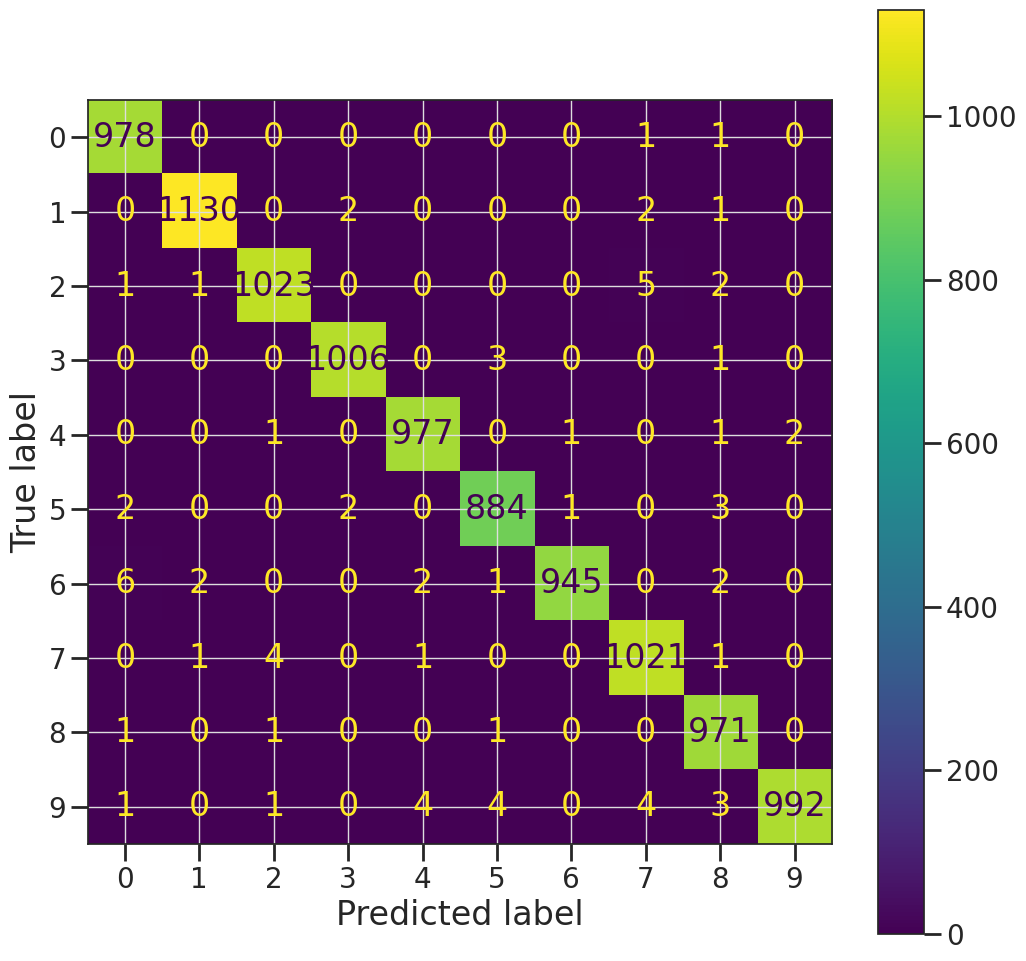

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix(y_trues, y_preds))
disp.plot(ax=ax)

plt.show()

# 1. Diffusion Architecures

## 1.1 Functions Giving Architectures

### 1.1.1 On Toy Data

In [ ]:
def make_toy_ddpm(
    x_sample_size: int, hidden_size: int, embedding_size: int,
    n_timesteps: int, n_blocks: int=4, act_fun: nn.Module=nn.GELU,
    reverse_process: nn.Module=DDPMReverseProcess
) -> nn.Module:
    model = reverse_process(
        GaussianBase((x_sample_size,)),
        ConstantLinearSchedule(n_timesteps),
        MLPTimeDependent(
            n_timesteps, embedding_size,
            x_sample_size, x_sample_size, [hidden_size]*n_blocks,
            mlp_act_funs=[act_fun]*n_blocks + [None],
            film_act_fun=act_fun
        ),
        n_timesteps
    )

    return model

def make_toy_vdm(
    x_sample_size: int, hidden_size: int, embedding_size: int,
    gamma_hid_size: int, n_timesteps: int, n_blocks: int=4,
    gamma_limits: Tuple[int, int]=(-6, 6), act_fun: nn.Module=nn.GELU,
    reverse_process: nn.Module=VDMReverseProcess
) -> nn.Module:
    model = reverse_process(
        GaussianBase((x_sample_size,)),
        LearnableLinearSchedule(
            n_timesteps, LinearMonotonicNetwork(1, gamma_hid_size),
            gamma_limits=gamma_limits
        ),
        MLPTimeDependent(
            n_timesteps, embedding_size,
            x_sample_size, x_sample_size, [hidden_size]*n_blocks,
            mlp_act_funs=[act_fun]*n_blocks + [None],
            film_act_fun=act_fun
        ),
        n_timesteps
    )

    return model

### 1.1.2 On MNIST

# 2. DMs on Toy Data

## 2.1 TwoGaussians

In [9]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [22]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for diff_type, make_fun in zip(
    ["ddpm", "vdm"], (
        make_toy_ddpm,
        lambda x_s, h, e, t: make_toy_vdm(x_s, h, e, 256, t)
    )
):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {diff_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            loss = model(x)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
    )

Number of ddpm Parameters: 25702.


Training: 100%|█████████▉| 2999/3000 [01:29<00:00, 39.30it/s, epoch=3/3, loss=⠀     10.7475]

Number of vdm Parameters: 26473.


Training: 100%|██████████| 3000/3000 [01:29<00:00, 33.44it/s, epoch=3/3, loss=⠀     10.7475]


### 2.1.1 Default Sampling

/home/alzub/tmp/ipykernel_4180038/3027161241.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


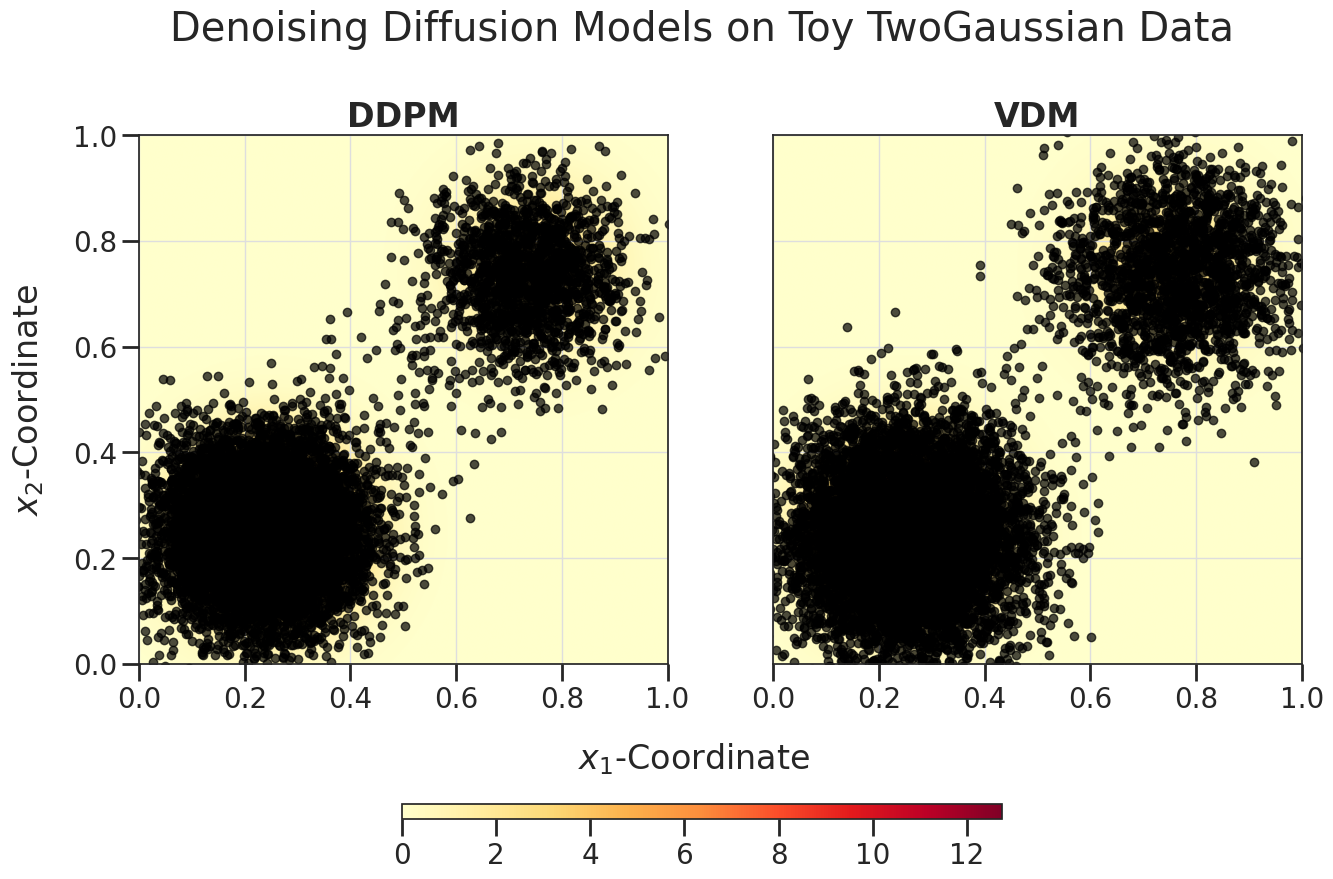

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
for i, (diff_type, make_fun) in enumerate(zip(
    ["ddpm", "vdm"], (
        make_toy_ddpm,
        lambda x_s, h, e, t: make_toy_vdm(x_s, h, e, 256, t)
    )
)):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(DIFF_NAME_MAP[diff_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Denoising Diffusion Models on Toy TwoGaussian Data", y=0.75)

plt.show()

### 2.1.2 Accelerated Sampling

/home/alzub/tmp/ipykernel_4180038/3654236442.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


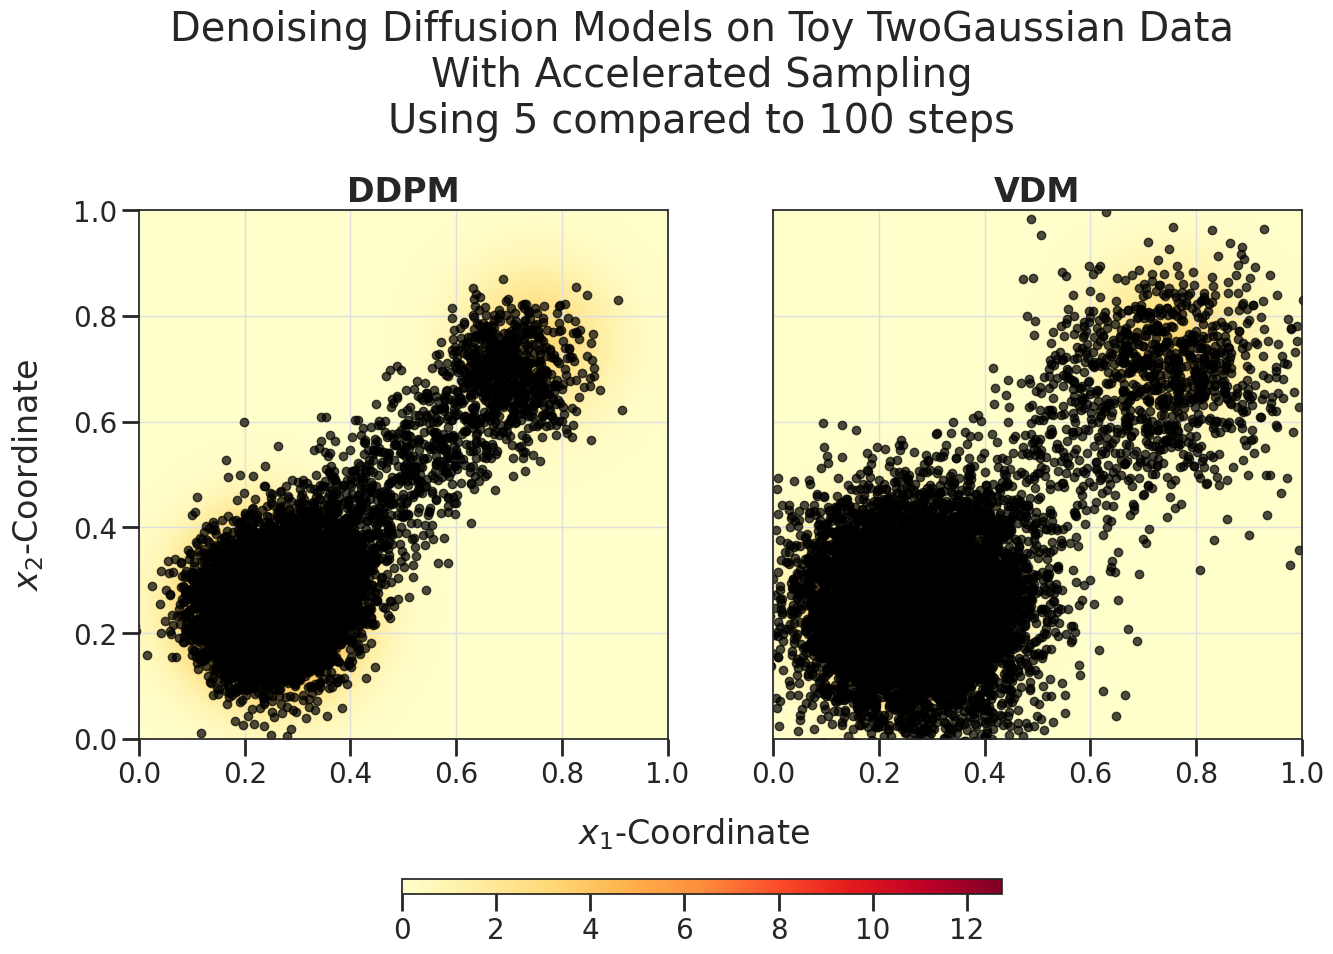

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
n_acc_steps = 5
for i, (diff_type, make_fun) in enumerate(zip(
    ["ddpm", "vdm"], (
        lambda x_s, h, e, t: make_toy_ddpm(
            x_s, h, e, t, reverse_process=DDIMReverseProcess),
        lambda x_s, h, e, t: make_toy_vdm(
            x_s, h, e, 256, t, reverse_process=DDIMReverseProcess)
    )
)):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample(
            (10000,), n_steps=n_acc_steps, start_time=1, variance=1.,
            spacing="logsnr",
            alpha_bar_in_logsnr=True if diff_type == "vdm" else False
        )
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(DIFF_NAME_MAP[diff_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Denoising Diffusion Models on Toy TwoGaussian Data"
        "\nWith Accelerated Sampling"
        f"\nUsing {n_acc_steps} compared to {n_timesteps} steps",
    y=0.80
)

plt.show()

## 2.2 Chequerboard

In [38]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

In [39]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

epochs = 3
lr = 1e-3

n_timesteps = 100
embedding_size = 24
hidden_size = 64

for diff_type, make_fun in zip(
    ["ddpm", "vdm"], (
        make_toy_ddpm,
        lambda x_s, h, e, t: make_toy_vdm(x_s, h, e, 256, t)
    )
):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {diff_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            loss = model(x)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
    )

Number of ddpm Parameters: 25702.


Training: 100%|█████████▉| 2999/3000 [02:50<00:00, 19.44it/s, epoch=3/3, loss=⠀     33.0639]

Number of vdm Parameters: 26473.


Training: 100%|██████████| 3000/3000 [02:52<00:00, 17.43it/s, epoch=3/3, loss=⠀     33.0639]


### 2.2.1 Default Sampling

/home/alzub/tmp/ipykernel_4180038/4123621024.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


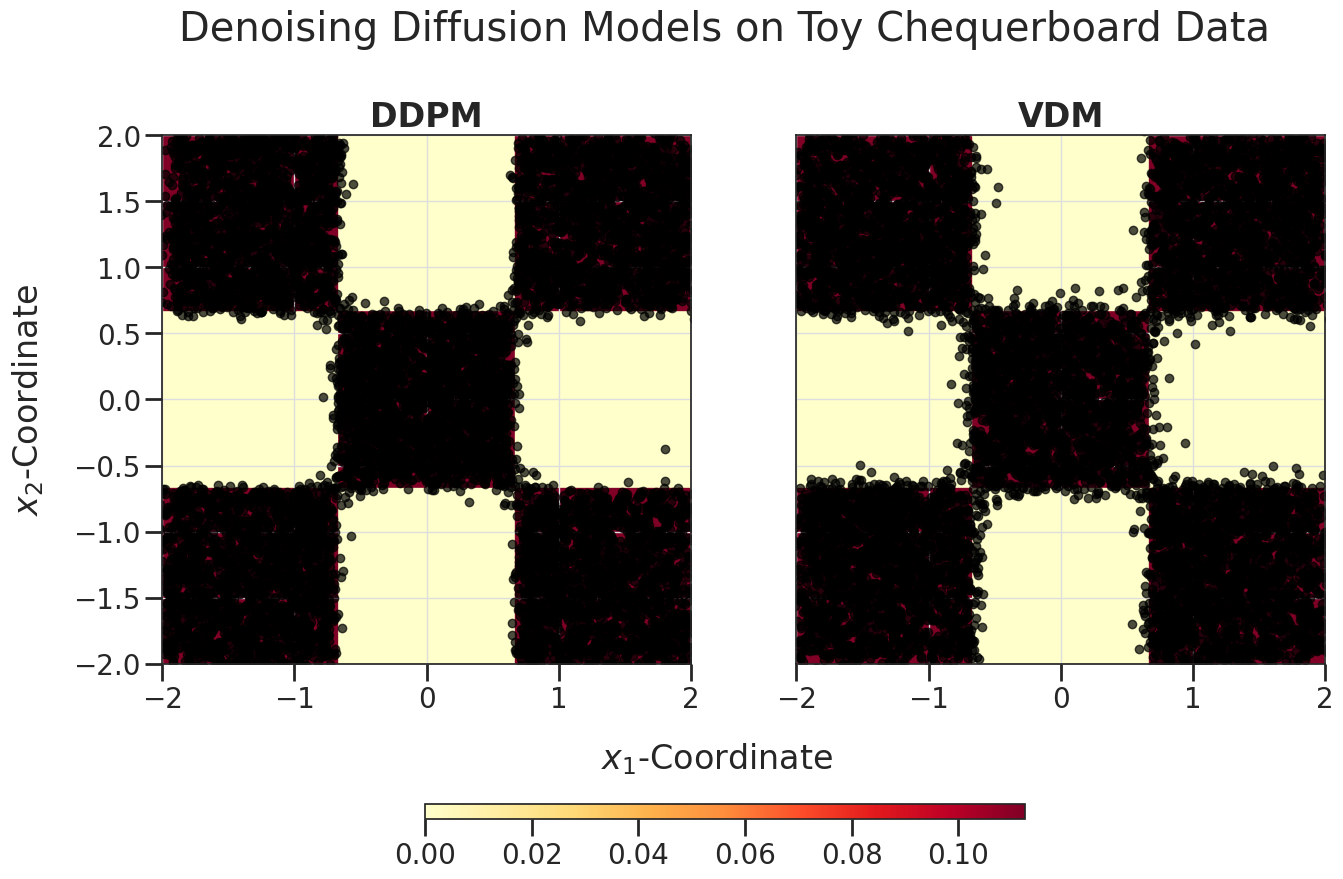

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
for i, (diff_type, make_fun) in enumerate(zip(
    ["ddpm", "vdm"], (
        make_toy_ddpm,
        lambda x_s, h, e, t: make_toy_vdm(x_s, h, e, 256, t)
    )
)):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(DIFF_NAME_MAP[diff_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Denoising Diffusion Models on Toy Chequerboard Data", y=0.75)

plt.show()

### 2.2.2 Accelerated Sampling

/home/alzub/tmp/ipykernel_4180038/3296497682.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


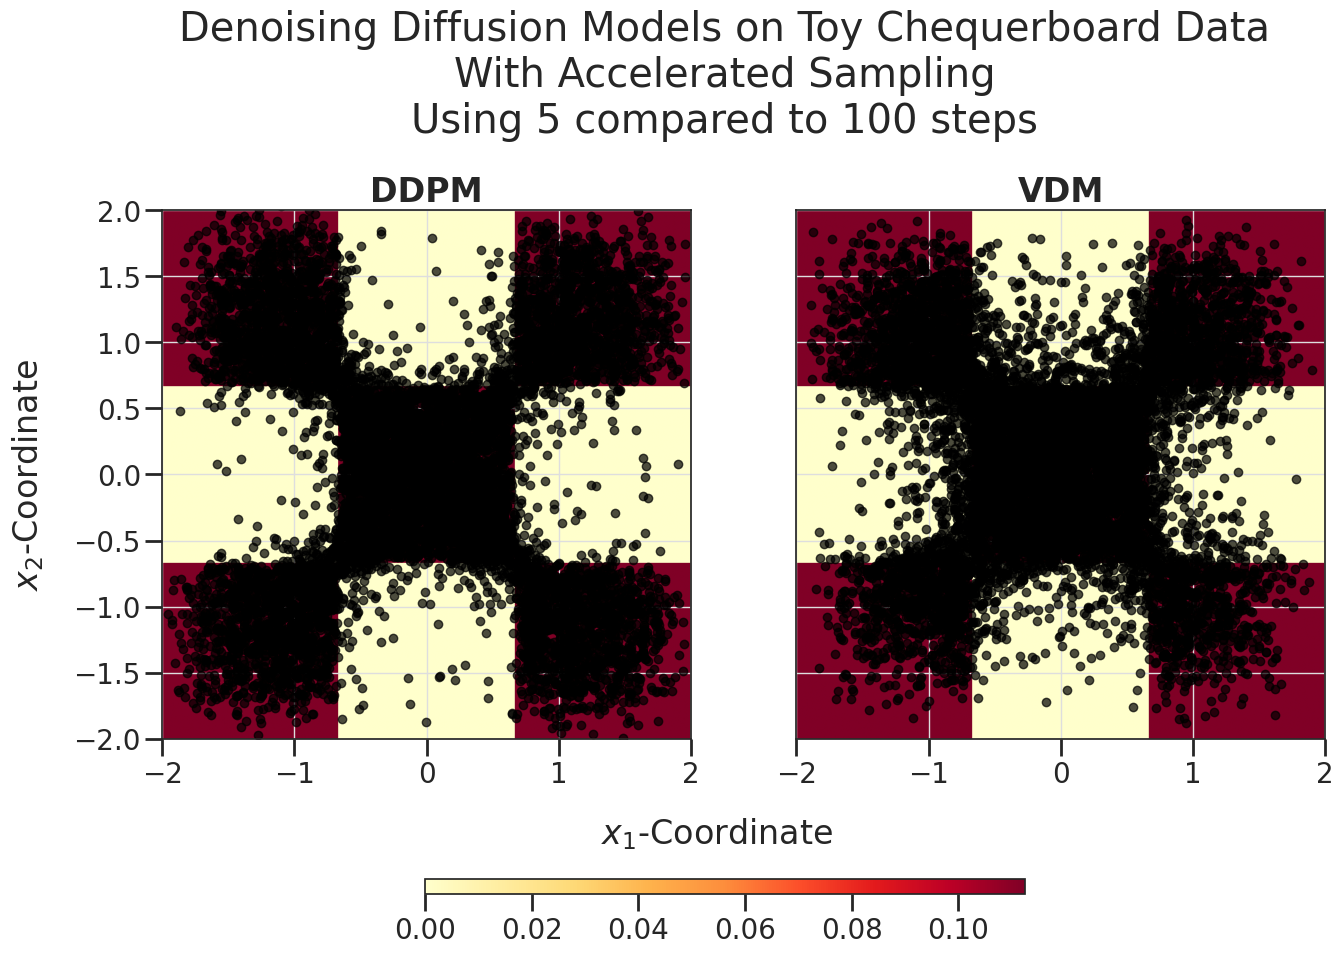

In [41]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 2, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.22, bottom=0.21, left=0.3, right=0.7)

epochs = 3
n_timesteps = 100
embedding_size = 24
hidden_size = 64
n_acc_steps = 5
for i, (diff_type, make_fun) in enumerate(zip(
    ["ddpm", "vdm"], (
        lambda x_s, h, e, t: make_toy_ddpm(
            x_s, h, e, t, reverse_process=DDIMReverseProcess),
        lambda x_s, h, e, t: make_toy_vdm(
            x_s, h, e, 256, t, reverse_process=DDIMReverseProcess)
    )
)):
    model = make_fun(
        x_sample_size, hidden_size, embedding_size, n_timesteps).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_{diff_type}_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample(
            (10000,), n_steps=n_acc_steps, start_time=1, variance=1.,
            spacing="logsnr",
            alpha_bar_in_logsnr=True if diff_type == "vdm" else False
        )
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20, x=-0.15)
    
    ax.set_title(DIFF_NAME_MAP[diff_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle(
    "Denoising Diffusion Models on Toy Chequerboard Data"
        "\nWith Accelerated Sampling"
        f"\nUsing {n_acc_steps} compared to {n_timesteps} steps",
    y=0.80
)

plt.show()

# 3. DMs on Easy, Real Data

## 3.1 MNIST

### 3.1.1 DDPM on MNIST

In [13]:
from hpo.basic_nn import create_unet
from hpo.utils import get_act_fun

In [19]:
ddpm_best_config = pd.read_csv(DATA_DIR / "nas/mnist_ddpm_unet_nas.csv")

In [20]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()

n_timesteps = 1000
n_classes = 10
score_net = create_unet(
    1, height, [
        32, 32, 64, 64, 128
    ], ddpm_best_config["n_hidden_layers"].item(),
    ddpm_best_config["conv_kernel_size"].item(),
    ddpm_best_config["pool_kernel_size"].item(),
    ddpm_best_config["pool_stride_size"].item(),
    [
        ddpm_best_config["pool_pad_size_1"].item(),
        ddpm_best_config["pool_pad_size_2"].item(),
        ddpm_best_config["pool_pad_size_3"].item(),
        ddpm_best_config["pool_pad_size_4"].item(),
        ddpm_best_config["pool_pad_size_5"].item(),
        ddpm_best_config["pool_pad_size_6"].item(),
        ddpm_best_config["pool_pad_size_7"].item()
    ], ddpm_best_config["tconv_kernel_size"].item(),
    n_timesteps, ddpm_best_config["time_emb_size"].item(),
    ddpm_best_config["class_emb_size"].item(), n_classes,
    activation_function=get_act_fun(ddpm_best_config["u_act_fun"].item()),
    unet_type="time_class_filmed",
    film_act_fun=get_act_fun(ddpm_best_config["f_act_fun"].item())
)
model = DDPMReverseProcess(
    GaussianBase((n_channels, height, width)),
    ConstantLinearSchedule(n_timesteps),
    score_net,
    n_timesteps
).to(DEVICE)

In [64]:
def make_mnist_diff_model(
    img_size: Tuple[int, int, int], time_embedding_size: int,
    class_embedding_size: int, n_timesteps: int, n_classes: int=10,
    unet_act_fun: nn.Module=nn.LogSigmoid, film_act_fun: nn.Module=nn.GELU,
    reverse_process: nn.Module=DDPMReverseProcess, sched_type: str="constant",
    gamma_hidden: int=1024
) -> nn.Module:
    if sched_type == "constant":
        sched = ConstantLinearSchedule(n_timesteps)
    else:
        sched = LearnableLinearSchedule(
            n_timesteps, LinearMonotonicNetwork(1, gamma_hidden))
    model = reverse_process(
        GaussianBase(img_size),
        sched,
        UNetTimeClassDependent(
            # FiLM pars
            n_timesteps, time_embedding_size, class_embedding_size, n_classes,
            # CNN pars
            img_size[1], img_size[0], [32, 64, 128, 256, 256],
            # convolution
            [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
            # pooling
            [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
            # transpose convolution
            [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
            unet_act_fun=unet_act_fun, film_act_fun=film_act_fun
        ),
        n_timesteps
    )

    return model

def make_mnist_ddim_model(
    img_size: Tuple[int, int, int], time_embedding_size: int,
    class_embedding_size: int, n_timesteps: int, n_classes: int=10,
    unet_act_fun: nn.Module=nn.LogSigmoid, film_act_fun: nn.Module=nn.GELU,
    sched_type: str="constant", gamma_hidden: int=1024
) -> nn.Module:
    if sched_type == "constant":
        sched = ConstantLinearSchedule(n_timesteps)
    else:
        sched = LearnableLinearSchedule(
            n_timesteps, LinearMonotonicNetwork(1, gamma_hidden))
    model = DDIMReverseProcess(
        GaussianBase(img_size),
        sched,
        UNetTimeClassDependent(
            # FiLM pars
            n_timesteps, time_embedding_size, class_embedding_size, n_classes,
            # CNN pars
            img_size[1], img_size[0], [32, 64, 128, 256, 256],
            # convolution
            [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
            # pooling
            [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
            # transpose convolution
            [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
            unet_act_fun=unet_act_fun, film_act_fun=film_act_fun
        ),
        n_timesteps
    )

    return model

In [ ]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

n_timesteps = 1000
time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for diff_type in ("ddpm", "vdm"):
    if diff_type == "ddpm":
        reverse_proc = DDPMReverseProcess
        sched_type = "constant"
        start_time = 0
    elif diff_type == "vdm":
        reverse_proc = VDMReverseProcess
        sched_type = "learnable"
        start_time = 1

    model = make_mnist_diff_model(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        n_timesteps, n_classes=n_classes, reverse_process=reverse_proc,
        sched_type=sched_type, gamma_hidden=gamma_hidden
    ).to(DEVICE)
    n_model_pars = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of {diff_type} Parameters: {n_model_pars}.")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(mnist_train_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")
    for epoch in range(epochs):
        for x, y in mnist_train_loader:
            optimizer.zero_grad()

            x, y = x.to(DEVICE), y.to(DEVICE)
            x = dequantize(x)
            loss = model(x, y=y, start_time=start_time)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
    )

Number of ddpm Parameters: 2998691.


Training: 100%|█████████▉| 23499/23500 [23:26<00:00, 14.99it/s, epoch=100/100, loss=⠀     15.1172]

Number of vdm Parameters: 3001766.


Training: 100%|██████████| 23500/23500 [23:27<00:00, 16.70it/s, epoch=100/100, loss=⠀     15.1172]


In [58]:
progress_bar.reset()

**Conditionally Trained Model**

In [ ]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

n_timesteps = 1000
time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for diff_type in ("ddpm", "vdm"):
    if diff_type == "ddpm":
        reverse_proc = DDPMReverseProcess
        sched_type = "constant"
        start_time = 0
    elif diff_type == "vdm":
        reverse_proc = VDMReverseProcess
        sched_type = "learnable"
        start_time = 1

    model = make_mnist_diff_model(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        n_timesteps, n_classes=n_classes, reverse_process=reverse_proc,
        sched_type=sched_type, gamma_hidden=gamma_hidden
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    model.eval()
    with torch.no_grad():
        y = torch.arange(
            10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
        samples = (
            model
                .sample((100,), y=y, start_time=start_time, show_path=False)
                .detach()
                .cpu()
        )
        samples = samples/2 + 0.5
        save_image(
            samples,
            SAMPLE_DIR / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.png",
            normalize=False, nrow=10
        )

/home/alzub/tmp/ipykernel_2064136/2037657915.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


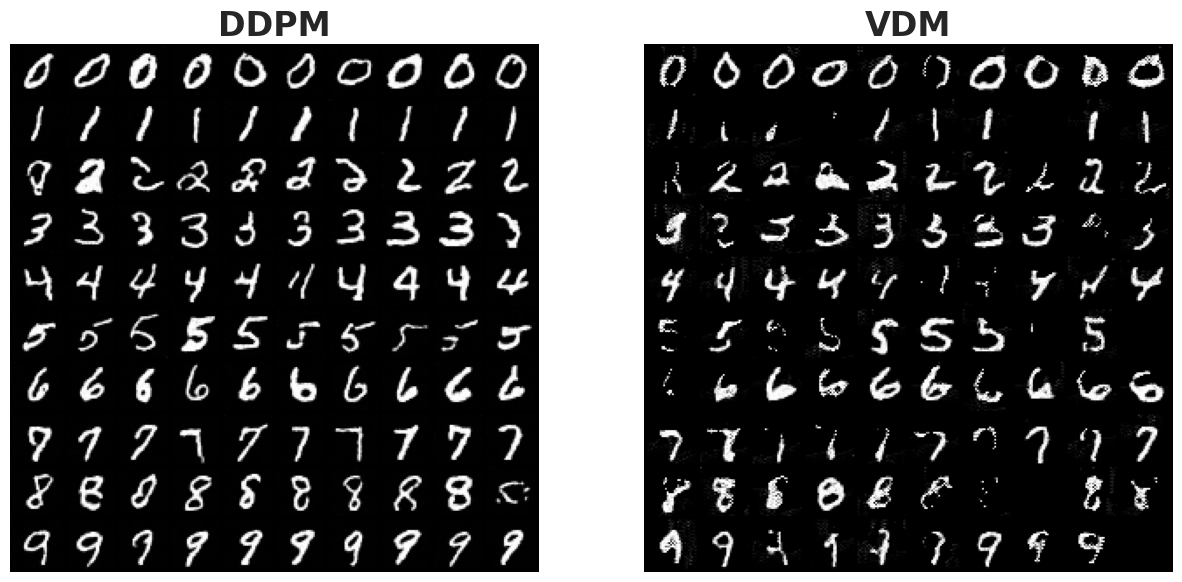

In [63]:
epochs = 100
n_timesteps = 1000

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

for i, diff_type in enumerate(("ddpm", "vdm")):
    img = WImage(
        filename=SAMPLE_DIR
            / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.png"
        )
    ax[i].imshow(img)
    ax[i].set_title(DIFF_NAME_MAP[diff_type], weight="bold")
    ax[i].axis("off")

plt.show()

**Accelerating Inference**

In [92]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

n_timesteps = 1000
nt_sampling = 10
time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
for diff_type in ("ddpm", "vdm"):
    if diff_type == "ddpm":
        sched_type = "constant"
        start_time = 0
        alpha_bar_in_logsnr = False
    elif diff_type == "vdm":
        sched_type = "learnable"
        start_time = 1
        alpha_bar_in_logsnr = True

    model = make_mnist_ddim_model(
        (n_channels, height, width), time_embedding_size, class_embedding_size,
        n_timesteps, n_classes=n_classes, sched_type=sched_type,
        gamma_hidden=gamma_hidden
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    model.eval()
    with torch.no_grad():
        y = torch.arange(
            10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
        samples = (
            model
                .sample(
                    (100,), n_steps=nt_sampling, y=y, start_time=start_time,
                    alpha_bar_in_logsnr=alpha_bar_in_logsnr, show_path=False
                )
                .detach()
                .cpu()
        )
        samples = samples/2 + 0.5
        save_image(
            samples,
            SAMPLE_DIR / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{nt_sampling}_n_t_acc.png",
            normalize=False, nrow=10
        )

/home/alzub/tmp/ipykernel_2064136/1570494560.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


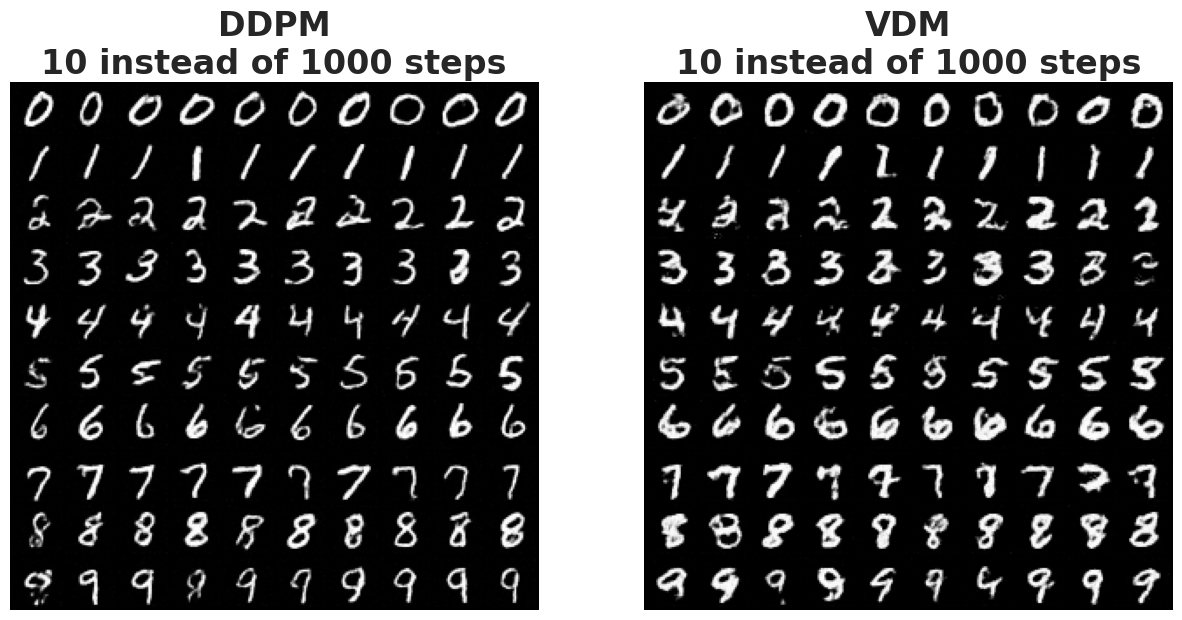

In [93]:
epochs = 100
n_timesteps = 1000
nt_sampling = 10

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

for i, diff_type in enumerate(("ddpm", "vdm")):
    img = WImage(
        filename=SAMPLE_DIR
            / f"mnist_{diff_type}_conditional_{epochs}_n_epochs_{nt_sampling}_n_t_acc.png"
        )
    ax[i].imshow(img)
    ax[i].set_title(
        DIFF_NAME_MAP[diff_type]
            + "\n"
            + f"{nt_sampling} instead of 1000 steps",
        weight="bold"
    )
    ax[i].axis("off")

plt.show()